# Qwen3-VL-4B-Instruct 교통사고 QA LoRA 미세조정

**실행 순서**: 위에서 아래로 순서대로 셀을 실행하세요.  
**핵심 수정 섹션**: `Section 4. 학습 설정` — 여기서 하이퍼파라미터를 바꾸세요.

---
| GPU | 권장 설정 |
|-----|----------|
| A100 (40GB) | bf16=True, fps=1.0, max_pixels=360×420 |
| T4 (16GB)   | fp16=True, fps=0.5, max_pixels=320×320 |


## Section 0. 환경 감지 및 경로 설정

Colab / 로컬 모두 이 셀 하나로 환경을 설정합니다.  
**로컬 실행 시**: `LOCAL_REPO_ROOT` 를 레포 루트 절대 경로로 수정하세요.  
**Colab 실행 시**: `COLAB_REPO_ROOT` 를 Drive 내 레포 경로로 수정하세요.

In [1]:
# !python -m training_runner.cli.build_pipeline_subset --raw-url "https://data.taeo-dev.com/dataset/traffic/1.Training/raw_data_231108_add/" --label-url "https://data.taeo-dev.com/dataset/traffic/1.Training/label_data_231108_add/"

In [1]:
from pathlib import Path

In [2]:
# ── 경로 직접 지정 ────────────────────────────────────────────────────────
LOCAL_REPO_ROOT = Path("/Users/shimsomin/Workplace/git_workspace/traffic-fault-platform")
COLAB_REPO_ROOT = Path("/content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform")

# ── 환경 감지 ─────────────────────────────────────────────────────────────
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

print(f"실행 환경: {'Google Colab' if IS_COLAB else '로컬'}")

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = COLAB_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT
    # 로컬: pip install 없이 sys.path에 src 경로 직접 추가
    for src in [
        REPO_ROOT / "apps/training-runner/src",
        REPO_ROOT / "packages/ai-core/src",
    ]:
        if str(src) not in sys.path and src.exists():
            sys.path.insert(0, str(src))
            print(f"sys.path 추가: {src}")

# ── 데이터 경로 ───────────────────────────────────────────────────────────
QA_JSON_PATH   = REPO_ROOT / "data/qa/qa_dataset.json"
RAW_VIDEO_ROOT = REPO_ROOT / "data/working/pipeline_subset/raw"
LABEL_ROOT     = REPO_ROOT / "data/working/pipeline_subset/label"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints/Qwen3_VL_4B_Instruct"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nREPO_ROOT: {REPO_ROOT}")
for name, p in [("QA JSON", QA_JSON_PATH), ("Raw 비디오", RAW_VIDEO_ROOT), ("Label", LABEL_ROOT)]:
    print(f"  {'✓' if p.exists() else '✗ 없음!'} {name}: {p}")

실행 환경: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

REPO_ROOT: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform
  ✓ QA JSON: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/data/qa/qa_dataset.json
  ✓ Raw 비디오: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/data/working/pipeline_subset/raw
  ✓ Label: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/data/working/pipeline_subset/label


## Section 1. 패키지 설치

- **Colab**: 아래 셀을 실행하세요 (런타임 재시작이 필요할 수 있습니다)
- **로컬**: Section 0에서 sys.path를 추가했으므로 이 셀은 건너뛰어도 됩니다  
  (단, `pip install qwen-vl-utils peft accelerate transformers av` 는 미리 설치되어 있어야 합니다)

In [4]:
!pip install qwen-vl-utils peft accelerate transformers av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 75.3 MB/s eta 0:00:00


In [5]:
import sys

if IS_COLAB:
    import subprocess

    # 외부 패키지 설치
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "transformers>=4.51.0", "peft>=0.11.0", "qwen-vl-utils>=0.0.8",
        "accelerate>=0.30.0", "av", "matplotlib", "seaborn"], check=True)

    # 로컬 패키지 설치
    for pkg_path in [
        REPO_ROOT / "packages/ai-core",
        REPO_ROOT / "apps/training-runner",
    ]:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-e", str(pkg_path), "-q"],
            capture_output=True, text=True
        )
        print(f"{pkg_path.name}: {'✓' if result.returncode == 0 else result.stderr}")
else:
    print("로컬 환경 — sys.path가 Section 0에서 이미 설정됨. 설치 생략.")

ai-core: ✓
training-runner: ✓


In [ ]:
import os
os.kill(os.getpid(), 9)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import torch
import json
from collections import Counter

from training_runner.configs.training_config import TrainingConfig
from transformers import AutoProcessor
from training_runner.dataset import build_dataloaders
from transformers import TrainingArguments, Trainer
from traffic_ai_core.Qwen3_VL_4B_Instruct.model.model import load_model
from peft import LoraConfig, TaskType, get_peft_model
from training_runner.dataset import TrafficAccidentQADataset
from training_runner.train import run_training
from peft import PeftModel
from qwen_vl_utils import process_vision_info

from google.colab import runtime

## Section 2. GPU 환경 확인

In [4]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU  : {gpu_name}")
    print(f"VRAM : {vram_gb:.1f} GB")

    if vram_gb >= 35:
        print("→ A100 감지: bf16=True, fps=1.0 권장")
        RECOMMENDED_BF16, RECOMMENDED_FP16 = True, False
        RECOMMENDED_FPS, RECOMMENDED_MAX_PIXELS = 1.0, 360 * 420
    else:
        print("→ T4/V100 감지: fp16=True, fps=0.5 권장 (메모리 절약)")
        RECOMMENDED_BF16, RECOMMENDED_FP16 = False, True
        RECOMMENDED_FPS, RECOMMENDED_MAX_PIXELS = 0.5, 320 * 320
else:
    print("GPU 없음 (CPU 실행 — 디버깅 전용)")
    RECOMMENDED_BF16, RECOMMENDED_FP16 = False, False
    RECOMMENDED_FPS, RECOMMENDED_MAX_PIXELS = 0.5, 320 * 320

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB
→ A100 감지: bf16=True, fps=1.0 권장


## Section 3. 데이터 확인 및 분포 시각화

In [5]:
with open(QA_JSON_PATH, encoding="utf-8") as f:
    qa_data = json.load(f)

print(f"QA 항목 수  : {len(qa_data)}")
print(f"QA쌍 / 항목 : {len(qa_data[0]['qa_pairs'])}")
print(f"최대 샘플 수: {len(qa_data) * len(qa_data[0]['qa_pairs'])}")

# 3방향 매칭 확인
raw_mp4s    = list(RAW_VIDEO_ROOT.rglob("*.mp4"))
label_jsons = list(LABEL_ROOT.rglob("*.json"))
raw_stems   = {p.stem for p in raw_mp4s}
label_stems = {p.stem for p in label_jsons}
qa_stems    = {Path(e['video_id']).stem for e in qa_data}
matched     = qa_stems & raw_stems & label_stems

print(f"\nRaw 비디오 : {len(raw_mp4s)}개")
print(f"Label JSON : {len(label_jsons)}개")
print(f"QA 항목    : {len(qa_data)}개")
print(f"3방향 매칭 : {len(matched)}개  → 학습 샘플: {len(matched) * 6}개")

QA 항목 수  : 80
QA쌍 / 항목 : 6
최대 샘플 수: 480

Raw 비디오 : 80개
Label JSON : 80개
QA 항목    : 80개
3방향 매칭 : 80개  → 학습 샘플: 480개


In [6]:
"""
if IS_COLAB:
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

cat_counter    = Counter(p.parent.name for p in raw_mp4s)
label_map_plot = {p.stem: p.parent.name for p in label_jsons}
qa_cat_counter = Counter(
    label_map_plot[Path(e['video_id']).stem]
    for e in qa_data if Path(e['video_id']).stem in label_map_plot
)
qt_counter = Counter(
    qa['question_type'] for e in qa_data for qa in e['qa_pairs']
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 카테고리별 비디오 수
cats = sorted(cat_counter)
b = axes[0].barh(cats, [cat_counter[c] for c in cats], color=sns.color_palette("Blues_d", len(cats)))
axes[0].bar_label(b, fmt='%d개', padding=3)
axes[0].set_title("카테고리별 비디오 수")

# 카테고리별 QA 항목 수
qcats = sorted(qa_cat_counter)
b2 = axes[1].barh(qcats, [qa_cat_counter[c] for c in qcats], color=sns.color_palette("Oranges_d", len(qcats)))
axes[1].bar_label(b2, fmt='%d개', padding=3)
axes[1].set_title("카테고리별 QA 항목 수")

# 질문 유형별 분포
types = list(qt_counter)
b3 = axes[2].bar(types, [qt_counter[t] for t in types], color=sns.color_palette("Greens_d", len(types)))
axes[2].bar_label(b3, fmt='%d개', padding=3)
axes[2].set_title("질문 유형별 분포")
plt.setp(axes[2].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()
"""

'\nif IS_COLAB:\n    import subprocess\n    subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)\n    fm._load_fontmanager(try_read_cache=False)\n    plt.rcParams[\'font.family\'] = \'NanumGothic\'\nplt.rcParams[\'axes.unicode_minus\'] = False\n\ncat_counter    = Counter(p.parent.name for p in raw_mp4s)\nlabel_map_plot = {p.stem: p.parent.name for p in label_jsons}\nqa_cat_counter = Counter(\n    label_map_plot[Path(e[\'video_id\']).stem]\n    for e in qa_data if Path(e[\'video_id\']).stem in label_map_plot\n)\nqt_counter = Counter(\n    qa[\'question_type\'] for e in qa_data for qa in e[\'qa_pairs\']\n)\n\nfig, axes = plt.subplots(1, 3, figsize=(20, 5))\n\n# 카테고리별 비디오 수\ncats = sorted(cat_counter)\nb = axes[0].barh(cats, [cat_counter[c] for c in cats], color=sns.color_palette("Blues_d", len(cats)))\naxes[0].bar_label(b, fmt=\'%d개\', padding=3)\naxes[0].set_title("카테고리별 비디오 수")\n\n# 카테고리별 QA 항목 수\nqcats = sorted(qa_cat_counter)\nb2 = axes[1].barh(qcats, [qa_

## Section 4. 학습 설정

In [7]:
config = TrainingConfig(
    qa_json_path   = str(QA_JSON_PATH),
    raw_video_root = str(RAW_VIDEO_ROOT),
    label_root     = str(LABEL_ROOT),
    checkpoint_dir = str(CHECKPOINT_DIR),

    model_id = "Qwen/Qwen3-VL-4B-Instruct",

    # LoRA
    lora_r       = 16,
    lora_alpha   = 32,
    lora_dropout = 0.05,

    # 학습
    num_train_epochs            = 5,
    learning_rate               = 2e-4,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,
    lr_scheduler_type           = "cosine",

    # 비디오
    fps        = RECOMMENDED_FPS,
    max_pixels = RECOMMENDED_MAX_PIXELS,
    max_seq_len = 512,

    # 정밀도
    bf16 = RECOMMENDED_BF16,
    fp16 = RECOMMENDED_FP16,

    train_ratio   = 0.7,
    val_ratio     = 0.2,
    seed           = 42,
    question_types = None,  # None = 전체 6종류
    report_to      = "none",
    dataloader_num_workers   = 4 #8
)

print(f"fps={config.fps}, max_pixels={config.max_pixels}")
print(f"lora_r={config.lora_r}, lr={config.learning_rate}, epochs={config.num_train_epochs}")
print(f"bf16={config.bf16}, fp16={config.fp16}")
print(f"dataloader_num_workers={config.dataloader_num_workers}")

fps=1.0, max_pixels=151200
lora_r=16, lr=0.0002, epochs=5
bf16=True, fp16=False
dataloader_num_workers=4


## Section 5. 데이터셋 구성 및 분포 확인

In [8]:
print('프로세서 로드 중...')
processor = AutoProcessor.from_pretrained(config.model_id)

print('데이터셋 구성 중 (QA ↔ 비디오 매칭 + 7:2:1 분할)...')
train_ds, val_ds, test_ds, _, _, _ = build_dataloaders(
    qa_json_path   = config.qa_json_path,
    raw_video_root = config.raw_video_root,
    label_root     = config.label_root,
    processor      = processor,
    train_ratio    = config.train_ratio,   # 0.7
    val_ratio      = config.val_ratio,     # 0.2  → test = 나머지 0.1
    seed           = config.seed,
    fps            = config.fps,
    max_pixels     = config.max_pixels,
    max_seq_len    = config.max_seq_len,
    question_types = config.question_types,
)

print(f'\n학습 샘플  : {len(train_ds)}개')
print(f'검증 샘플  : {len(val_ds)}개')
print(f'테스트 샘플: {len(test_ds)}개')


프로세서 로드 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

데이터셋 구성 중 (QA ↔ 비디오 매칭 + 7:2:1 분할)...
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 480 (전체 매칭: 480)
[build_dataloaders] 학습: 56개 비디오 / 336샘플 | 검증: 16개 비디오 / 96샘플 | 테스트: 8개 비디오 / 48샘플
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 336 (전체 매칭: 480)
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 96 (전체 매칭: 480)
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 48 (전체 매칭: 480)

학습 샘플  : 336개
검증 샘플  : 96개
테스트 샘플: 48개


/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4364 (\N{HANGUL CHOSEONG CIEUC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4449 (\N{HANGUL JUNGSEONG A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4370 (\N{HANGUL CHOSEONG HIEUH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4455 (\N{HANGUL JUNGSEONG YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4540 (\N{HANGUL JONGSEONG IEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4352 (\N{HANGUL CHOSEONG KIYEOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1513/3958435991.py:22: UserWarning: Glyph 4461 (\N{HANGUL JUNGSEONG YO}) missing from font(s) DejaVu Sans.
  plt.tigh

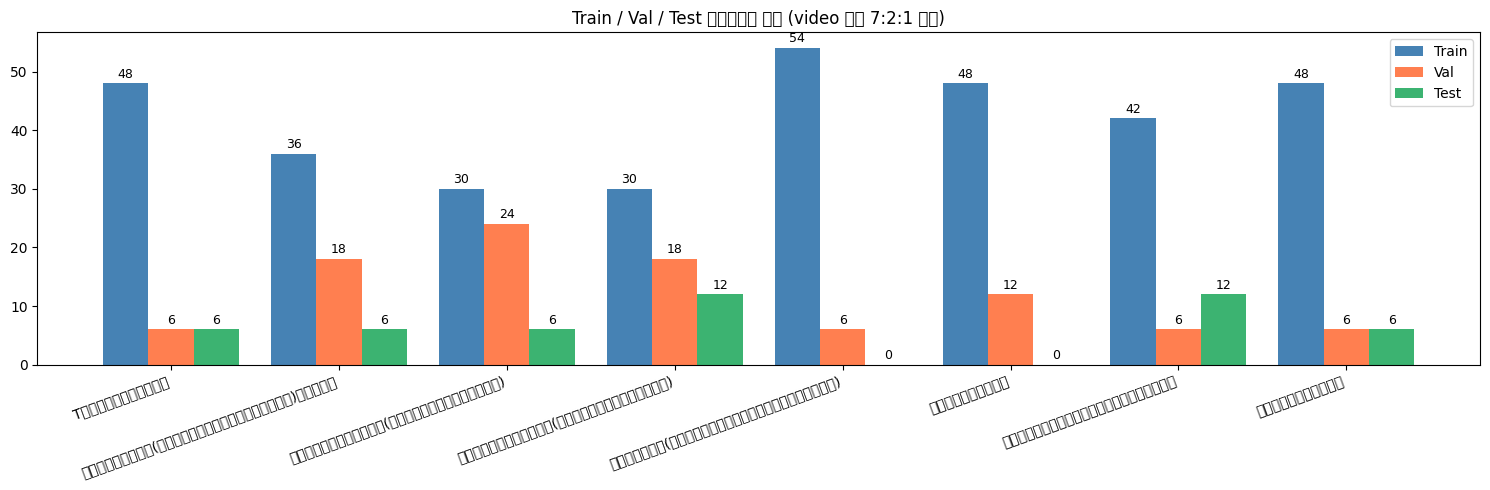

학습  56개 비디오 / 336샘플
검증  16개 비디오 /  96샘플
테스트  8개 비디오 /  48샘플


In [9]:
# Train / Val / Test 카테고리 분포
train_dist = train_ds.get_distribution()
val_dist   = val_ds.get_distribution()
test_dist  = test_ds.get_distribution()
all_cats   = sorted(
    set(train_dist['by_category'])
    | set(val_dist['by_category'])
    | set(test_dist['by_category'])
)
x, w = range(len(all_cats)), 0.27

fig, ax = plt.subplots(figsize=(15, 5))
b1 = ax.bar([i - w     for i in x], [train_dist['by_category'].get(c, 0) for c in all_cats], width=w, label='Train', color='steelblue')
b2 = ax.bar([i         for i in x], [val_dist['by_category'].get(c, 0)   for c in all_cats], width=w, label='Val',   color='coral')
b3 = ax.bar([i + w     for i in x], [test_dist['by_category'].get(c, 0)  for c in all_cats], width=w, label='Test',  color='mediumseagreen')
for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%d', padding=2, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(all_cats, rotation=20, ha='right')
ax.set_title('Train / Val / Test 카테고리별 분포 (video 단위 7:2:1 분할)')
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"학습  {train_dist['unique_videos']:2}개 비디오 / {train_dist['total']:3}샘플\n"
    f"검증  {val_dist['unique_videos']:2}개 비디오 / {val_dist['total']:3}샘플\n"
    f"테스트 {test_dist['unique_videos']:2}개 비디오 / {test_dist['total']:3}샘플"
)


In [10]:
# 샘플 1개 레이블 마스킹 확인
sample      = train_ds[0]
input_ids   = sample['input_ids']
labels      = sample['labels']
answer_mask = labels != -100

print(f"전체 시퀀스 길이 : {len(input_ids)} 토큰")
print(f"마스킹 구간      : {(~answer_mask).sum().item()} 토큰 (-100)")
print(f"답변 구간        : {answer_mask.sum().item()} 토큰")
print(f"디코딩된 답변    : {processor.tokenizer.decode(input_ids[answer_mask], skip_special_tokens=True)!r}")

qwen-vl-utils using torchcodec to read video.
Asked to sample `fps` frames per second but no video metadata was provided which is required when sampling with `fps`. Defaulting to `fps=24`. Please provide `video_metadata` for more accurate results.


전체 시퀀스 길이 : 394 토큰
마스킹 구간      : 386 토큰 (-100)
답변 구간        : 8 토큰
디코딩된 답변    : 'T자형 교차로\n'


## Section 6. 학습 실행

In [11]:
# Smoke test (2 스텝) — OOM / 코드 오류 사전 확인

base_model, _ = load_model(config.model_id)
if config.gradient_checkpointing:
    base_model.enable_input_require_grads()

smoke_model = get_peft_model(base_model, LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=config.lora_r, lora_alpha=config.lora_alpha,
    target_modules=config.target_modules, lora_dropout=config.lora_dropout, bias=config.lora_bias,
))
smoke_model.print_trainable_parameters()

Trainer(
    model=smoke_model,
    args=TrainingArguments(
        output_dir="/tmp/smoke_test", max_steps=2,
        per_device_train_batch_size=1,
        bf16=config.bf16, fp16=config.fp16,
        gradient_checkpointing=config.gradient_checkpointing,
        remove_unused_columns=False, label_names=["labels"],
        report_to="none", logging_steps=1,
    ),
    train_dataset=train_ds,
    data_collator=TrafficAccidentQADataset.collate_fn,
).train()

print("\n✓ Smoke test 통과")
del smoke_model, base_model
torch.cuda.empty_cache()

[TrafficAccidentVLM] 로드 중: Qwen/Qwen3-VL-4B-Instruct


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

[TrafficAccidentVLM] 완료 | GPU: 8.9GB
trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388


Step,Training Loss
1,4.751632
2,2.945650



✓ Smoke test 통과


In [12]:
# 실제 학습
run_training(config)

Qwen3-VL-4B LoRA 미세조정 설정
------------------------------------------------------------
  모델              : Qwen/Qwen3-VL-4B-Instruct
  LoRA rank / alpha : 16 / 32
  학습률            : 0.0002
  에폭              : 5
  배치 크기         : 1 × 4
  fps / max_pixels  : 1.0 / 151200
  bf16 / fp16       : True / False
  체크포인트        : /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct
  GPU               : NVIDIA A100-SXM4-40GB (42.4GB)

[1/7] 모델 로드 중...
[TrafficAccidentVLM] 로드 중: Qwen/Qwen3-VL-4B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[TrafficAccidentVLM] 완료 | GPU: 17.9GB
[2/7] Gradient Checkpointing 활성화...
[3/7] LoRA 적용 중...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388

[4/7] 데이터셋 구성 중...
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 480 (전체 매칭: 480)
[build_dataloaders] 학습: 56개 비디오 / 336샘플 | 검증: 16개 비디오 / 96샘플 | 테스트: 8개 비디오 / 48샘플
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 336 (전체 매칭: 480)
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 96 (전체 매칭: 480)
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 48 (전체 매칭: 480)

[학습 데이터 분포]
  T자형교차로                     48샘플  █████████
  고속도로(자동차전용도로)포함   36샘플  ███████
  사거리교차로(신호등없음)     30샘플  ██████
  사거리교차로(신호등있음)     30샘플  ██████
  주차장(또는차도가아닌장소)   54샘플  ██████████
  직선도로                       48샘플  █████████
  차도와차도가아닌장소           42샘플  ████████
  회전교차로                      48샘플  █████████
  합계                        

Step,Training Loss,Validation Loss
50,0.915993,1.052923
100,0.514676,0.681696
150,0.564747,0.561059
200,0.441844,0.567613
250,0.396044,0.465923
300,0.397960,0.469347
350,0.354613,0.441842
400,0.278229,0.439143



[7/7] 어댑터 저장 중...
  저장 완료: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct/final_adapter



  eval_loss: 0.3491

========== 학습 완료 ==========


In [13]:
# best.pt 저장
# run_training()은 load_best_model_at_end=True로 동작하므로,
# 학습 종료 시점의 final_adapter/가 val_loss 최소 체크포인트를 담고 있다.
# safetensors 포맷의 어댑터 가중치를 PyTorch .pt 포맷으로 변환 저장한다.
# (base model 재로드 없이 safetensors만 읽으므로 메모리 추가 사용 없음)

from safetensors.torch import load_file

final_adapter_path = CHECKPOINT_DIR / "final_adapter"
safetensors_path   = final_adapter_path / "adapter_model.safetensors"
best_pt_path       = CHECKPOINT_DIR / "best.pt"

if safetensors_path.exists():
    adapter_weights = load_file(str(safetensors_path))  # {param_name: tensor}
    torch.save(adapter_weights, str(best_pt_path))
    size_mb = best_pt_path.stat().st_size / 1e6
    print(f"best.pt 저장 완료: {best_pt_path}  ({size_mb:.1f} MB)")
    print(f"포함된 파라미터 수: {len(adapter_weights)}개")
else:
    print(f"⚠ {safetensors_path} 없음 — run_training() 완료 여부 확인")


best.pt 저장 완료: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct/best.pt  (132.3 MB)
포함된 파라미터 수: 504개


## Section 7. 체크포인트 확인

In [14]:
final_adapter_path = CHECKPOINT_DIR / "final_adapter"

if final_adapter_path.exists():
    print(f"✓ {final_adapter_path}")
    for f in sorted(final_adapter_path.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")
else:
    print("⚠ final_adapter 없음 — 학습 완료 여부 확인")

✓ /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct/final_adapter
  README.md  (0.0 MB)
  adapter_config.json  (0.0 MB)
  adapter_model.safetensors  (132.2 MB)
  chat_template.jinja  (0.0 MB)
  processor_config.json  (0.0 MB)
  tokenizer.json  (11.4 MB)
  tokenizer_config.json  (0.0 MB)


## Section 8. (옵션) 추론 테스트

In [15]:
base_model, processor = load_model(config.model_id)
model = PeftModel.from_pretrained(base_model, str(CHECKPOINT_DIR / "final_adapter"))
model.eval()

test = val_ds._samples[0]
print(f"질문: {test.question}")
print(f"정답: {test.answer}")

messages = [
    {"role": "system", "content": TrafficAccidentQADataset.DEFAULT_SYSTEM_PROMPT},
    {"role": "user", "content": [
        {"type": "video", "video": str(test.video_path), "fps": config.fps, "max_pixels": config.max_pixels},
        {"type": "text",  "text": test.question},
    ]},
]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = {k: v.to(model.device) for k, v in
          processor(text=[text], images=image_inputs, videos=video_inputs, return_tensors="pt").items()}

with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=64, do_sample=False)

pred = processor.tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print(f"\n예측: {pred}")
print(f"정답: {test.answer}")
print(f"{'✓' if pred.strip() == test.answer.strip() else '✗'}")

[TrafficAccidentVLM] 로드 중: Qwen/Qwen3-VL-4B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[TrafficAccidentVLM] 완료 | GPU: 8.9GB
질문: 이 사고는 어떤 장소에서 발생했는가?
정답: 회전교차로


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



예측: 직선 도로
정답: 회전교차로
✗


In [ ]:
# 모든 학습 및 저장 절차가 끝난 후 실행
print("모든 작업이 완료되었습니다. 런타임을 종료합니다.")
runtime.unassign()

모든 작업이 완료되었습니다. 런타임을 종료합니다.
